project resmet

In [3]:
# ==========================================
# 1. Import Libraries
# ==========================================

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# ==========================================
# 2. Load Dataset
# ==========================================

df = pd.read_csv("dataset_phishing.csv")

print("Dataset shape:", df.shape)

# remove url column if exists
if "url" in df.columns:
    df = df.drop(columns=["url"])

# remove duplicates / missing values
df = df.drop_duplicates()
df = df.dropna()

# --- PERBAIKAN: MAPPING YANG LEBIH TEGAS ---
# Map semua kemungkinan nilai ke 0 (aman) atau 1 (phishing)
# .map() akan mengubah nilai yang tidak dikenal menjadi NaN
mapping = {
    'legitimate': 0, 
    'phishing': 1, 
    -1: 0, 
    0: 0, 
    1: 1
}
df["status"] = df["status"].map(mapping)

# Hapus baris yang gagal di-map (jika ada nilai aneh)
df = df.dropna(subset=["status"])

# PAKSA TIPE DATA MENJADI INTEGER (Menghilangkan error Unknown label type)
df["status"] = df["status"].astype(int)

print("Dataset after cleaning:", df.shape)
print("Unique labels in status:", df["status"].unique())


# ==========================================
# 3. Split Features and Target
# ==========================================

X = df.drop(columns=["status"])
y = df["status"]

print("Feature count:", X.shape[1])


# ==========================================
# 4. Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


# ==========================================
# 5. Initialize Models
# ==========================================

models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        eval_metric="logloss",
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    )

}


# ==========================================
# 6. Train and Evaluate Models
# ==========================================

results = []

for name, model in models.items():

    print("\nTraining:", name)

    # Proses training sekarang akan berjalan lancar karena y_train sudah berupa integer
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions)
    rec = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    cm = confusion_matrix(y_test, predictions)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)

    print("Confusion Matrix:")
    print(cm)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    })

# --- AUTO SAVE MODEL (Penting!) ---
# Simpan model terbaik untuk digunakan di script lain secara otomatis
joblib.dump(models["XGBoost"], "phishing_model.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")
print("\n✅ Model and features saved successfully!")


# ==========================================
# 7. Result Comparison Table
# ==========================================

results_df = pd.DataFrame(results)

print("\nModel Comparison")
print(results_df)

# save results
results_df.to_csv("model_results.csv", index=False)

print("\nResults saved to model_results.csv")

Dataset shape: (11430, 89)
Dataset after cleaning: (11256, 88)
Unique labels in status: [0 1]
Feature count: 87
Train size: (9004, 87)
Test size: (2252, 87)

Training: Random Forest
Accuracy: 0.9591474245115453
Precision: 0.9601809954751132
Recall: 0.9567177637511272
F1 Score: 0.9584462511291779
Confusion Matrix:
[[1099   44]
 [  48 1061]]

Training: XGBoost
Accuracy: 0.9640319715808171
Precision: 0.9622302158273381
Recall: 0.9648331830477908
F1 Score: 0.9635299414678073
Confusion Matrix:
[[1101   42]
 [  39 1070]]

Training: LightGBM
[LightGBM] [Info] Number of positive: 4432, number of negative: 4572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010828 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4880
[LightGBM] [Info] Number of data points in the train set: 9004, number of used features: 73
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.492226 -> initscore=-0.031100
[LightGBM] [Info] Star

Matplotlib is building the font cache; this may take a moment.



Top 20 Important Features
                 Feature  Importance
85          google_index    0.163802
86             page_rank    0.108291
83           web_traffic    0.079171
56         nb_hyperlinks    0.077815
20                nb_www    0.039105
82            domain_age    0.034586
58   ratio_extHyperlinks    0.034475
46     longest_word_path    0.027123
50           phish_hints    0.027054
74           safe_anchor    0.026859
57   ratio_intHyperlinks    0.024692
62  ratio_extRedirection    0.019490
0             length_url    0.019117
1        length_hostname    0.017326
25      ratio_digits_url    0.016811
44     longest_words_raw    0.015454
49         avg_word_path    0.015360
40           char_repeat    0.014446
39      length_words_raw    0.014288
78       domain_in_title    0.013065


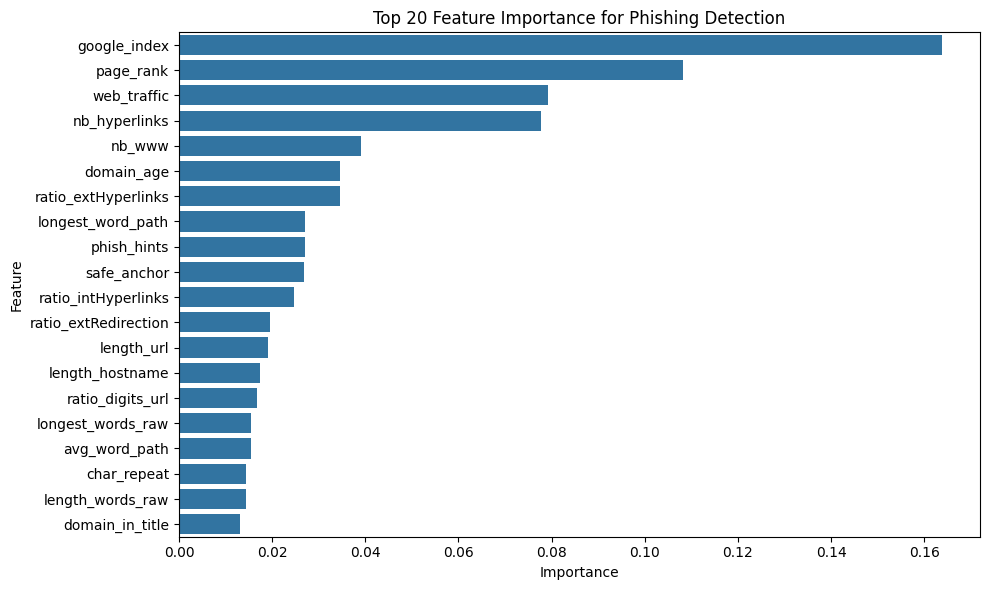

In [4]:
# ==========================================
# Feature Importance
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# use trained Random Forest
model = models["Random Forest"]

# get importance values
importance = model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# sort
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# show top 20
top20 = importance_df.head(20)

print("\nTop 20 Important Features")
print(top20)

# plot
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=top20)

plt.title("Top 20 Feature Importance for Phishing Detection")
plt.tight_layout()
plt.show()

c:\Users\Acer\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


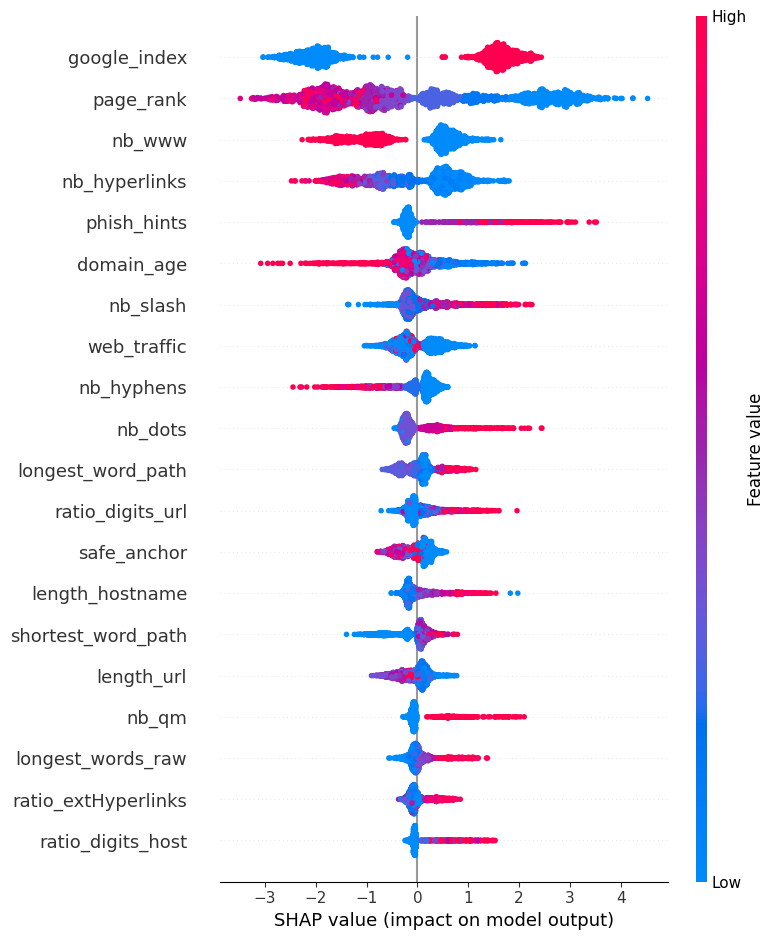

In [5]:
# ==========================================
# SHAP Explainability
# ==========================================

import shap

# choose best model (example: XGBoost)
model = models["XGBoost"]

# create SHAP explainer
explainer = shap.TreeExplainer(model)

# calculate shap values
shap_values = explainer.shap_values(X_test)

# summary plot
shap.summary_plot(shap_values, X_test)

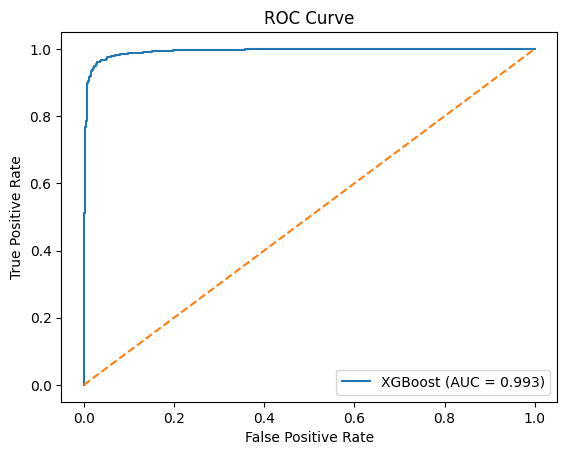

In [6]:
from sklearn.metrics import roc_curve, auc

import matplotlib.pyplot as plt

model = models["XGBoost"]

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="XGBoost (AUC = %0.3f)" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [7]:
import joblib
import pandas as pd
import numpy as np
import re
from urllib.parse import urlparse
import os

# ==============================================================================
# PETUNJUK PENTING:
# Sebelum menjalankan script ini, Anda harus menyimpan model dari notebook Anda.
# Jalankan kode ini di sel terakhir notebook (.ipynb) Anda:
#
# import joblib
# model_terbaik = models["XGBoost"] # atau model lain yang Anda pilih
# joblib.dump(model_terbaik, "phishing_model.pkl")
# joblib.dump(X.columns.tolist(), "feature_columns.pkl")
# ==============================================================================

def extract_url_features(url, feature_cols):
    """
    Fungsi untuk mengekstrak fitur leksikal dari URL agar sesuai dengan dataset.
    """
    parsed = urlparse(url)
    hostname = parsed.hostname if parsed.hostname else ""
    path = parsed.path if parsed.path else ""
    
    # Inisialisasi semua fitur dengan 0
    features = {col: 0 for col in feature_cols}
    
    # --- Ekstraksi Fitur Leksikal ---
    features['length_url'] = len(url)
    features['length_hostname'] = len(hostname)
    features['nb_dots'] = url.count('.')
    features['nb_hyphens'] = url.count('-')
    features['nb_at'] = url.count('@')
    features['nb_qm'] = url.count('?')
    features['nb_and'] = url.count('&')
    features['nb_or'] = 1 if '|' in url else 0
    features['nb_eq'] = url.count('=')
    features['nb_underscore'] = url.count('_')
    features['nb_tilde'] = url.count('~')
    features['nb_percent'] = url.count('%')
    features['nb_slash'] = url.count('/')
    features['nb_star'] = url.count('*')
    features['nb_colon'] = url.count(':')
    features['nb_comma'] = url.count(',')
    features['nb_semicolumn'] = url.count(';')
    features['nb_dollar'] = url.count('$')
    features['nb_space'] = url.count(' ') + url.count('%20')
    features['nb_www'] = 1 if 'www' in hostname.lower() else 0
    features['nb_com'] = 1 if '.com' in url.lower() else 0
    features['nb_dslash'] = url.count('//')
    features['http_in_path'] = 1 if 'http' in path.lower() else 0
    features['https_token'] = 1 if parsed.scheme == 'https' else 0
    
    # Rasio Digit
    digits_url = [c for c in url if c.isdigit()]
    features['ratio_digits_url'] = len(digits_url) / len(url) if len(url) > 0 else 0
    
    digits_host = [c for c in hostname if c.isdigit()]
    features['ratio_digits_host'] = len(digits_host) / len(hostname) if len(hostname) > 0 else 0
    
    # IP Address
    ip_pattern = r"^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}$"
    features['ip'] = 1 if re.match(ip_pattern, hostname) else 0
    
    # Shortening Service
    shorteners = r"bit\.ly|goo\.gl|shorte\.st|go2l\.ink|x\.co|ow\.ly|t\.co|tinyurl|tr\.im|is\.gd|cli\.gs"
    features['shortening_service'] = 1 if re.search(shorteners, hostname) else 0

    # Prefix/Suffix
    features['prefix_suffix'] = 1 if '-' in hostname else 0

    # Konversi ke DataFrame sesuai urutan kolom asli
    return pd.DataFrame([features])[feature_cols]


In [8]:
def prediksi_link(url):
    model_path = "phishing_model.pkl"
    cols_path = "feature_columns.pkl"

    # Cek apakah file model ada
    if not os.path.exists(model_path) or not os.path.exists(cols_path):
        print("\n[!] ERROR: File 'phishing_model.pkl' atau 'feature_columns.pkl' tidak ditemukan.")
        print("[!] Silakan simpan model dari notebook Anda terlebih dahulu (lihat instruksi di dalam file ini).\n")
        return

    try:
        # Load Model dan Kolom
        model = joblib.load(model_path)
        feature_cols = joblib.load(cols_path)
        
        # Ekstrak & Prediksi
        data_input = extract_url_features(url, feature_cols)
        pred = model.predict(data_input)[0]
        prob = model.predict_proba(data_input)[0][1]
        
        print("\n" + "="*50)
        print(f"URL: {url}")
        print("-" * 50)
        if pred == 1:
            print("HASIL: ⚠️  PHISHING (BAHAYA)")
        else:
            print("HASIL: ✅  LEGITIMATE (AMAN)")
        print(f"Probabilitas Phishing: {prob:.2%}")
        print("="*50 + "\n")
        
    except Exception as e:
        print(f"Terjadi kesalahan saat prediksi: {e}")

if __name__ == "__main__":
    url_input = input("Masukkan URL yang ingin dicek: ")
    prediksi_link(url_input)


URL: https://haha.phising.com
--------------------------------------------------
HASIL: ✅  LEGITIMATE (AMAN)
Probabilitas Phishing: 10.95%

